In [14]:
pip install requests pandas tqdm

Note: you may need to restart the kernel to use updated packages.


In [15]:
 #תא 2 — הגדרות + פונקציות עזר
# ============================================================
import requests
import pandas as pd
from tqdm.notebook import tqdm
from datetime import datetime, timezone, timedelta
from pathlib import Path
import time

BASE = "https://open-bus-stride-api.hasadna.org.il"

# ── Timezone ──────────────────────────────────────────────
# אפריל  = UTC+3 (שעון קיץ)
# ינואר  = UTC+2 (שעון חורף) — שנה ל-hours=2
ISRAEL_TZ = timezone(timedelta(hours=3))

def to_israel(s):
    if not s: return None
    dt = datetime.fromisoformat(s)
    if dt.tzinfo is None:
        dt = dt.replace(tzinfo=timezone.utc)
    return dt.astimezone(ISRAEL_TZ)

def fmt_time(s):
    dt = to_israel(s)
    return dt.strftime("%H:%M:%S") if dt else ""

def fmt_date(s):
    dt = to_israel(s)
    return dt.strftime("%d/%m/%Y") if dt else ""

def day_he(s):
    days = ["שני","שלישי","רביעי","חמישי","שישי","שבת","ראשון"]
    dt = to_israel(s)
    return days[dt.weekday()] if dt else ""

def round_hour(s):
    dt = to_israel(s)
    return f"{dt.hour:02d}:00" if dt else ""

def dur_min(a, b):
    if not a or not b: return ""
    m = round((datetime.fromisoformat(b) - datetime.fromisoformat(a)).total_seconds() / 60)
    return m if 0 < m < 600 else ""

def haversine(lat1, lon1, lat2, lon2):
    from math import radians, sin, cos, sqrt, atan2
    R = 6371
    dlat, dlon = radians(lat2-lat1), radians(lon2-lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

def fetch_with_retry(url, params, max_retries=5, timeout=120):
    for attempt in range(max_retries):
        try:
            r = requests.get(url, params=params, timeout=timeout)
            r.raise_for_status()
            return r.json()
        except (requests.ReadTimeout, requests.ConnectionError):
            wait = (attempt + 1) * 5
            print(f"  ⚠️ ניסיון {attempt+1}/{max_retries} — ממתין {wait}ש'...")
            time.sleep(wait)
        except Exception as e:
            print(f"  ❌ שגיאה: {e}"); raise
    raise Exception("נכשל אחרי כל הניסיונות")

print("✅ הגדרות נטענו")



✅ הגדרות נטענו


In [16]:

# ============================================================
# תא 3 — שליפת נסיעות
# ── תיקון timezone:
#    06/04 21:00 UTC  =  07/04 00:00 ישראל (UTC+3)
#    13/04 20:59 UTC  =  13/04 23:59 ישראל (UTC+3)
# ── לינואר (UTC+2):
#    FETCH_FROM = "2024-01-04T22:00:00Z"
#    FETCH_TO   = "2024-01-11T21:59:59Z"
# ============================================================

WEEK_LABEL = "apr2024"
OUT_FILE   = Path(f"telaviv_buses_{WEEK_LABEL}.csv")
FETCH_FROM = "2024-04-06T21:00:00Z"   # = 07/04 00:00 ישראל
FETCH_TO   = "2024-04-13T20:59:59Z"   # = 13/04 23:59 ישראל

def fetch_all_rides():
    params = {
        "limit": 100,
        "scheduled_start_time_from": FETCH_FROM,
        "scheduled_start_time_to":   FETCH_TO,
        "gtfs_route__route_long_name_contains": "תל אביב",
    }
    total = fetch_with_retry(
        f"{BASE}/siri_rides/list",
        {**params, "limit": 1, "get_count": "true"}
    )
    print(f"סה\"כ {total:,} נסיעות")

    rides, offset = [], 0
    pbar = tqdm(total=total, unit="נסיעות")
    while True:
        params["offset"] = offset
        batch = fetch_with_retry(f"{BASE}/siri_rides/list", params)
        if not isinstance(batch, list) or not batch: break
        rides.extend(batch)
        pbar.update(len(batch))
        if len(batch) < 100: break
        offset += len(batch)
        time.sleep(0.15)
    pbar.close()
    print(f"✅ {len(rides):,} נסיעות נשלפו")
    return rides

rides = fetch_all_rides()



סה"כ 92,548 נסיעות


  0%|          | 0/92548 [00:00<?, ?נסיעות/s]

  ⚠️ ניסיון 1/5 — ממתין 5ש'...
✅ 92,548 נסיעות נשלפו


In [17]:



# ============================================================
# תא 4 — שליפת תחנות (cache חכם — פעם אחת לכל route)
# ============================================================
def fetch_stops(gtfs_ride_id):
    d = fetch_with_retry(f"{BASE}/gtfs_ride_stops/list", {
        "limit": 200,
        "gtfs_ride_ids": gtfs_ride_id,
        "order_by": "stop_sequence"
    })
    return d if isinstance(d, list) else []

# בנה מיפוי: route_id → נסיעה אחת לדוגמה
seen = {}
for ride in rides:
    rid = ride.get("gtfs_ride__gtfs_route_id")
    if rid and rid not in seen and ride.get("gtfs_ride_id"):
        seen[rid] = ride["gtfs_ride_id"]

print(f"שולף תחנות ל-{len(seen):,} routes ייחודיים...")
route_cache = {}
for route_id, gtfs_ride_id in tqdm(seen.items()):
    try:
        stops = fetch_stops(gtfs_ride_id)
        dist  = sum(
            haversine(
                stops[i-1]["gtfs_stop__lat"], stops[i-1]["gtfs_stop__lon"],
                stops[i]["gtfs_stop__lat"],   stops[i]["gtfs_stop__lon"]
            )
            for i in range(1, len(stops))
            if stops[i-1].get("gtfs_stop__lat") and stops[i].get("gtfs_stop__lat")
        )
        route_cache[route_id] = {
            "from_city":  stops[0].get("gtfs_stop__city","")  if stops else "",
            "from_stop":  stops[0].get("gtfs_stop__name","")  if stops else "",
            "to_city":    stops[-1].get("gtfs_stop__city","") if stops else "",
            "to_stop":    stops[-1].get("gtfs_stop__name","") if stops else "",
            "stop_count": len(stops),
            "dist_km":    round(dist, 3),
        }
    except:
        route_cache[route_id] = {}
    time.sleep(0.15)

print(f"✅ cache מוכן: {len(route_cache):,} routes")



שולף תחנות ל-3,390 routes ייחודיים...


  0%|          | 0/3390 [00:00<?, ?it/s]

  ⚠️ ניסיון 1/5 — ממתין 5ש'...
✅ cache מוכן: 3,390 routes


In [18]:


# ============================================================
# תא 5 — בנה DataFrame ושמור CSV
# ============================================================
rows = []
for ride in rides:
    dep = ride.get("scheduled_start_time","")
    arr  = ride.get("gtfs_ride__end_time","")
    plan = dur_min(dep, arr)
    act  = ride.get("duration_minutes") if ride.get("duration_minutes",0) > 0 else ""
    diff = (act - plan) if isinstance(plan,int) and isinstance(act,int) else ""
    s    = route_cache.get(ride.get("gtfs_ride__gtfs_route_id"), {})
    dist = s.get("dist_km", 0)

    rows.append({
        "תאריך":                   fmt_date(dep),
        "יום":                     day_he(dep),
        "שעה (עגולה)":            round_hour(dep),
        "מספר קו":                 ride.get("gtfs_route__route_short_name",""),
        "שם הקו":                  ride.get("gtfs_route__route_long_name", ""),
        "route_id":               ride.get("gtfs_route__line_ref",""),
        "route_mkt":              ride.get("gtfs_route__route_mkt",""),
        "כיוון":                   ride.get("gtfs_route__route_direction", ""),
        "אלטרנטיבה":               ride.get("gtfs_route__route_alternative",""),
        "חברה (agency_name)":      ride.get("gtfs_route__agency_name",     ""),
        "סוג מסלול (route_type)":  "אוטובוס" if ride.get("gtfs_route__route_type")=="3" else ride.get("gtfs_route__route_type",""),
        "עיר מוצא":                s.get("from_city",""),
        "תחנת מוצא":               s.get("from_stop",""),
        "עיר יעד":                 s.get("to_city",  ""),
        "תחנת יעד":                s.get("to_stop",  ""),
        "כמות תחנות":              s.get("stop_count",""),
        "אורך מסלול (קמ)":         dist or "",
        "זמן יציאה מתוכנן":        fmt_time(dep),
        "זמן הגעה מתוכנן":         fmt_time(arr),
        "משך מתוכנן (דק)":         plan,
        "משך בפועל (דק)":          act,
        "הפרש (דק)":               diff,
        "מהירות מתוכננת (קמש)":    round(dist/(plan/60),1) if dist and isinstance(plan,int) and plan>0 else "",
        "מהירות בפועל (קמש)":      round(dist/(act/60), 1) if dist and isinstance(act,int)  and act>0  else "",
        "gtfs_route_id":           ride.get("gtfs_ride__gtfs_route_id",""),
        "gtfs_ride_id":            ride.get("gtfs_ride_id",""),
        "מזהה SIRI":               ride.get("id",""),
    })

df = pd.DataFrame(rows)
df.to_csv(OUT_FILE, index=False, encoding="utf-8-sig")
print(f"✅ נשמר: {OUT_FILE.resolve()}")
print(f"📊 {df.shape[0]:,} שורות × {df.shape[1]} עמודות")

# בדיקת תפלגות ימים — צפוי ~15,000 לכל יום
print("\nתפלגות לפי יום:")
print(df["יום"].value_counts().sort_index())

✅ נשמר: C:\Users\shaha\Documents\DS_course\public_transport_ML\notebooks\telaviv_buses_apr2024.csv
📊 92,548 שורות × 27 עמודות

תפלגות לפי יום:
יום
חמישי    13016
ראשון    19926
רביעי    12672
שבת       2057
שישי      8285
שלישי    17353
שני      19239
Name: count, dtype: int64


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

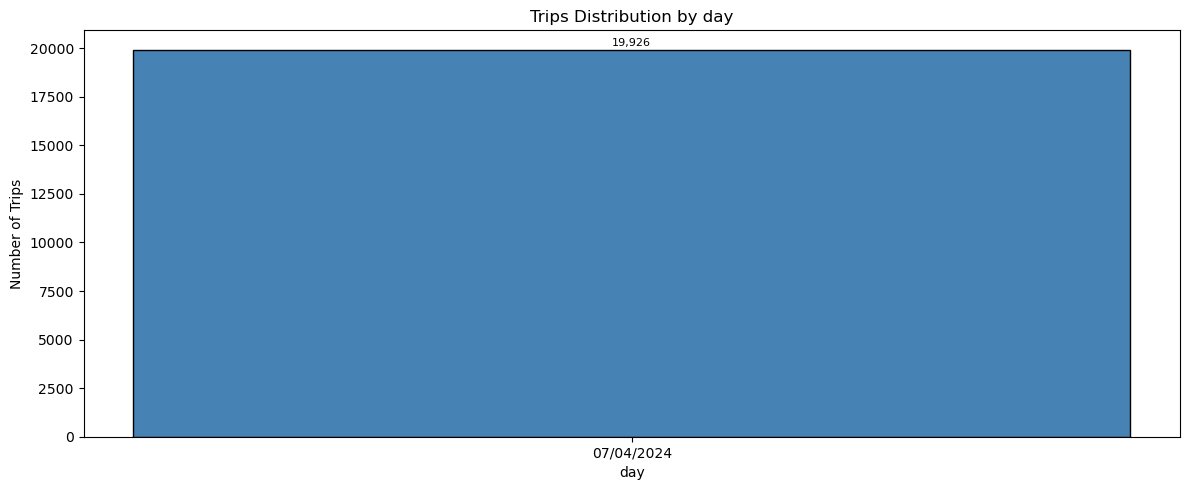

In [7]:
plt.figure(figsize=(12, 5))
counts = df['תאריך'].value_counts().sort_index()
bars = plt.bar(counts.index, counts.values, color='steelblue', edgecolor='black')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f'{int(bar.get_height()):,}',
        ha='center', va='bottom', fontsize=8
    )

plt.title('Trips Distribution by day')
plt.xlabel('day')
plt.ylabel('Number of Trips')
plt.xticks(counts.index, rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 5))
counts = df['שעה (עגולה)'].value_counts().sort_index()
bars = plt.bar(counts.index, counts.values, color='steelblue', edgecolor='black')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f'{int(bar.get_height()):,}',
        ha='center', va='bottom', fontsize=8
    )

plt.title('Trips Distribution by hour')
plt.xlabel('day')
plt.ylabel('Number of Trips')
plt.xticks(counts.index, rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
df.to_csv("telaviv_buses_apr2024_fixed.csv", index=False, encoding="utf-8-sig")
print(f"✅ נשמר: telaviv_buses_apr2024_fixed.csv")
print(f"📊 {df.shape[0]:,} שורות × {df.shape[1]} עמודות")